In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import kagglehub
from torch.utils.data import Subset
import numpy as np
import cv2
from collections import Counter
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import random
 
print("✅ Imports ready")

✅ Imports ready


In [2]:
save_dir = '/kaggle/working/model_checkpoints'
os.makedirs(save_dir, exist_ok=True)

CHECKPOINT_PATH = os.path.join(save_dir, "improved_model_checkpoint.pth")
CHECKPOINT_PATH_LOAD = os.path.join("/kaggle/input/datasets/rishabhagrawal3112/dual-model-checkpoin/dual_model_checkpoint.pth")
BEST_MODEL_PATH = os.path.join("/kaggle/input/datasets/sauravchaudhary3112/improved-best-model/improved_best_model.pth")
print(f"✅ Checkpoints will save to: {save_dir}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

✅ Checkpoints will save to: /kaggle/working/model_checkpoints
Using device: cuda


In [3]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL — Download BOTH datasets and merge them                      ║
# ╚══════════════════════════════════════════════════════════════════════╝
import shutil

# Download both
path_a = kagglehub.dataset_download("sartajbhuvaji/brain-tumor-classification-mri")
path_b = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Dataset A (Figshare/sartaj):", path_a)
print("Dataset B (masoud)         :", path_b)

# ── Inspect both structures ───────────────────────────────────────────
for name, path in [("sartaj", path_a), ("masoud", path_b)]:
    print(f"\n{name}:")
    for root, dirs, files in os.walk(path):
        depth = root.replace(path, '').count(os.sep)
        if depth <= 2 and files:
            cls = os.path.basename(root)
            print(f"   {cls}: {len(files)} images")

Dataset A (Figshare/sartaj): /kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri
Dataset B (masoud)         : /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset

sartaj:
   no_tumor: 395 images
   pituitary_tumor: 827 images
   meningioma_tumor: 822 images
   glioma_tumor: 826 images
   no_tumor: 105 images
   pituitary_tumor: 74 images
   meningioma_tumor: 115 images
   glioma_tumor: 100 images

masoud:
   pituitary: 1400 images
   notumor: 1400 images
   meningioma: 1400 images
   glioma: 1400 images
   pituitary: 400 images
   notumor: 400 images
   meningioma: 400 images
   glioma: 400 images


In [4]:
import shutil

MERGED_DIR = '/kaggle/working/merged_dataset'
TEST_DIR   = '/kaggle/working/test_dataset'

CLASS_MAP = {
    'glioma_tumor'    : 'glioma',
    'meningioma_tumor': 'meningioma',
    'no_tumor'        : 'notumor',
    'pituitary_tumor' : 'pituitary',
    'glioma'          : 'glioma',
    'meningioma'      : 'meningioma',
    'notumor'         : 'notumor',
    'pituitary'       : 'pituitary',
}

for cls in ['glioma', 'meningioma', 'notumor', 'pituitary']:
    os.makedirs(os.path.join(MERGED_DIR, cls), exist_ok=True)
    os.makedirs(os.path.join(TEST_DIR,   cls), exist_ok=True)

# FIX: dst_root is now a parameter
def copy_images(src_root, split_name, dst_root, prefix):
    split_dir = os.path.join(src_root, split_name)
    if not os.path.exists(split_dir):
        print(f'  ⚠️  {split_dir} not found'); return 0
    copied = 0
    for cls_folder in os.listdir(split_dir):
        cls_path = os.path.join(split_dir, cls_folder)
        if not os.path.isdir(cls_path): continue
        unified = CLASS_MAP.get(cls_folder.lower().strip())
        if unified is None: continue
        dst_dir = os.path.join(dst_root, unified)
        for fname in os.listdir(cls_path):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                shutil.copy2(os.path.join(cls_path, fname),
                             os.path.join(dst_dir, f'{prefix}_{fname}'))
                copied += 1
    return copied

# TRAIN ← sartaj Training + masoud Training
n1 = copy_images(path_a, 'Training', MERGED_DIR, 'sartaj_train')
n2 = copy_images(path_b, 'Training', MERGED_DIR, 'masoud_train')

# TEST ← masoud Testing only (completely separate, never seen during training)
e1 = copy_images(path_b, 'Testing',  TEST_DIR,   'masoud_test')

print(f'Train: sartaj {n1} + masoud {n2} = {n1+n2}')
print(f'Test : masoud {e1}')

print('\nClass counts:')
print(f'  {"Class":<15} {"Train":>8} {"Test":>8}')
for cls in ['glioma', 'meningioma', 'notumor', 'pituitary']:
    n_tr = len(os.listdir(os.path.join(MERGED_DIR, cls)))
    n_te = len(os.listdir(os.path.join(TEST_DIR,   cls)))
    print(f'  {cls:<15} {n_tr:>8} {n_te:>8}')

Train: sartaj 2870 + masoud 5600 = 8470
Test : masoud 1600

Class counts:
  Class              Train     Test
  glioma              2226      400
  meningioma          2222      400
  notumor             1795      400
  pituitary           2227      400


In [5]:
# Training transforms — augmentation only on train split
train_transform_gray = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
 
# Test transforms — NO augmentation
test_transform_gray = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
 
print("✅ Transforms ready")

✅ Transforms ready


In [6]:
class ImprovedBrainTumorDataset(Dataset):
    """
    Loads MRI images with coordinate convolutions for anatomical priors
    Returns: (grayscale_tensor_with_coords, label)
    """
    
    VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')
    
    def __init__(self, root, mode='train'):
        self.root = root
        self.mode = mode
        
        # Discover classes
        self.classes = sorted([
            d for d in os.listdir(root)
            if os.path.isdir(os.path.join(root, d))
        ])
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        
        # Gather samples
        self.samples = []
        for cls in self.classes:
            cls_dir = os.path.join(root, cls)
            for fname in sorted(os.listdir(cls_dir)):
                if fname.lower().endswith(self.VALID_EXTENSIONS):
                    self.samples.append(
                        (os.path.join(cls_dir, fname), self.class_to_idx[cls])
                    )
        
        print(f"  Loaded {len(self.samples)} images | "
              f"{len(self.classes)} classes: {self.classes}")
    
    def _get_transform(self):
        if self.mode == 'train':
            return train_transform_gray
        return test_transform_gray
    
    def set_mode(self, mode):
        assert mode in ('train', 'test'), "mode must be 'train' or 'test'"
        self.mode = mode
    
    @staticmethod
    def add_coordinate_channels(img_tensor):
        """Add normalized (x,y) coordinate channels for anatomical priors"""
        _, H, W = img_tensor.shape
        
        # Create coordinate grids normalized to [-1, 1]
        x_coords = torch.linspace(-1, 1, W)
        y_coords = torch.linspace(-1, 1, H)
        
        x_grid = x_coords.unsqueeze(0).repeat(H, 1)
        y_grid = y_coords.unsqueeze(1).repeat(1, W)
        
        # Add as additional channels
        coords = torch.stack([x_grid, y_grid], dim=0)
        return torch.cat([img_tensor, coords], dim=0)
    
    def __getitem__(self, index):
        path, label = self.samples[index]
        img = Image.open(path).convert('L')
        
        transform = self._get_transform()
        gray_tensor = transform(img)  # (1, 224, 224)
        
        # Add coordinate channels for anatomical priors
        enhanced_tensor = self.add_coordinate_channels(gray_tensor)  # (3, 224, 224)
        
        return enhanced_tensor, label
        
    def __len__(self):
        return len(self.samples)

In [7]:
# CORRECT — completely separate datasets, no overlap possible
train_ds = ImprovedBrainTumorDataset(MERGED_DIR, mode='train')
test_ds  = ImprovedBrainTumorDataset(TEST_DIR,   mode='test')

print(f'Train : {len(train_ds):,}')
print(f'Test  : {len(test_ds):,}  ← held-out, never seen during training')

# Class-weighted sampler with focal loss strategy
train_labels      = [label for _, label in train_ds.samples]
label_counts      = Counter(train_labels)
class_weights_arr = [len(train_labels) / label_counts[i]
                     for i in range(len(train_ds.classes))]
sample_weights    = [class_weights_arr[l] for l in train_labels]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights),
                                replacement=True)

train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler,
                          num_workers=4, pin_memory=True, drop_last=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False,
                          num_workers=4, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Test  batches : {len(test_loader)}')

  Loaded 8470 images | 4 classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
  Loaded 1600 images | 4 classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Train : 8,470
Test  : 1,600  ← held-out, never seen during training
Train batches : 264
Test  batches : 50


In [8]:
def mixup_data(gray, labels, alpha=0.3):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(gray.size(0)).to(gray.device)
    return (lam * gray + (1 - lam) * gray[idx],
            labels, labels[idx], lam)

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


class DropBlock2d(nn.Module):
    def __init__(self, drop_prob=0.1, block_size=3):
        super().__init__()
        self.drop_prob  = drop_prob
        self.block_size = block_size

    def forward(self, x):
        if not self.training or self.drop_prob == 0:
            return x
        B, C, H, W = x.shape
        seed = torch.rand(B, C, H, W, device=x.device)
        seed = (seed < self.drop_prob / (self.block_size ** 2)).float()
        mask = nn.functional.max_pool2d(
            seed, kernel_size=(self.block_size, self.block_size),
            stride=1, padding=self.block_size // 2)
        mask = (1 - mask[:, :, :H, :W])
        return x * mask * (mask.numel() / (mask.sum() + 1e-6))

In [9]:
class FocalLoss(nn.Module):
    """Focal Loss for class imbalance - automatically focuses on hard examples"""
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    
    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss


class ImprovedCNNWithIterativeAttention(nn.Module):
    """
    Architecture with ALL improvements:
    1. Coordinate convolutions (via input channels)
    2. Multi-scale feature extraction (ASPP)
    3. Iterative Self-Attention → BiLSTM → Self-Attention → BiLSTM
    4. Layer-wise positional encodings
    5. Attention-weighted pooling (replaces average pooling)
    6. Multi-resolution auxiliary losses
    7. Boundary detection head
    """
    def __init__(self, num_classes=4, nhead=8, num_iterations=2):
        super().__init__()
        self.num_iterations = num_iterations
        
        # ── 1. Multi-scale CNN with coordinate conv (3 input channels: image + x + y) ──
        def make_cnn():
            return nn.Sequential(
                # Block 1
                nn.Conv2d(3, 32, 3, padding=1),
                nn.BatchNorm2d(32), nn.GELU(),
                nn.Conv2d(32, 32, 3, padding=1),
                nn.BatchNorm2d(32), nn.GELU(),
                nn.MaxPool2d(2), DropBlock2d(0.10, 3),

                # Block 2
                nn.Conv2d(32, 64, 3, padding=1),
                nn.BatchNorm2d(64), nn.GELU(),
                nn.Conv2d(64, 64, 3, padding=1),
                nn.BatchNorm2d(64), nn.GELU(),
                nn.MaxPool2d(2), DropBlock2d(0.10, 3),

                # Block 3
                nn.Conv2d(64, 128, 3, padding=1),
                nn.BatchNorm2d(128), nn.GELU(),
                nn.Conv2d(128, 128, 3, padding=1),
                nn.BatchNorm2d(128), nn.GELU(),
                nn.MaxPool2d(2), DropBlock2d(0.15, 5),

                # Block 4
                nn.Conv2d(128, 256, 3, padding=1),
                nn.BatchNorm2d(256), nn.GELU(),
                nn.Conv2d(256, 256, 3, padding=1),
                nn.BatchNorm2d(256), nn.GELU(),
                nn.MaxPool2d(2), DropBlock2d(0.15, 5),
            )

        self.cnn = make_cnn()  # Output: (B, 256, 14, 14)
        
        # ── 2. Atrous Spatial Pyramid Pooling (ASPP) for multi-scale ──────
        self.aspp = nn.ModuleList([
            nn.Conv2d(256, 256, 3, padding=1, dilation=1),   # scale 1
            nn.Conv2d(256, 256, 3, padding=2, dilation=2),   # scale 2
            nn.Conv2d(256, 256, 3, padding=4, dilation=4),   # scale 4
            nn.Conv2d(256, 256, 3, padding=8, dilation=8),   # scale 8
        ])
        self.aspp_fusion = nn.Conv2d(256 * 4, 512, 1)
        
        feat_dim = 512
        seq_len = 196  # 14×14 spatial grid

        # ── 3. Layer-wise positional encodings (refreshed at each layer) ──
        self.pos_enc_initial = nn.Parameter(torch.randn(1, seq_len, feat_dim) * 0.02)
        self.pos_enc_attn1 = nn.Parameter(torch.randn(1, seq_len, feat_dim) * 0.02)
        self.pos_enc_lstm1 = nn.Parameter(torch.randn(1, seq_len, feat_dim) * 0.02)
        self.pos_enc_attn2 = nn.Parameter(torch.randn(1, seq_len, feat_dim) * 0.02)
        self.pos_enc_lstm2 = nn.Parameter(torch.randn(1, seq_len, feat_dim) * 0.02)

        # ── 4. Iterative Self-Attention and BiLSTM modules ────────────────
        self.self_attn_1 = nn.MultiheadAttention(feat_dim, nhead, batch_first=True, dropout=0.15)
        self.norm_attn_1 = nn.LayerNorm(feat_dim)
        
        self.bilstm_1 = nn.LSTM(feat_dim, 256, num_layers=1,
                                batch_first=True, bidirectional=True, dropout=0.0)
        self.norm_lstm_1 = nn.LayerNorm(feat_dim)
        
        self.self_attn_2 = nn.MultiheadAttention(feat_dim, nhead, batch_first=True, dropout=0.10)
        self.norm_attn_2 = nn.LayerNorm(feat_dim)
        
        self.bilstm_2 = nn.LSTM(feat_dim, 256, num_layers=1,
                                batch_first=True, bidirectional=True, dropout=0.0)
        self.norm_lstm_2 = nn.LayerNorm(feat_dim)

        # ── 5. Attention-weighted pooling (returns weighted sum + attention weights) ──
        self.pool_attention = nn.Linear(feat_dim, 1)

        # ── 6. Boundary detection head (auxiliary loss) ───────────────────
        self.boundary_head = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),
            nn.GELU(),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.GELU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.GELU(),
            nn.Conv2d(32, 1, 1),
            nn.Sigmoid()
        )
        
        # ── 7. Multi-resolution auxiliary classifiers ─────────────────────
        self.aux_classifier_14 = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, num_classes)
        )
        
        self.aux_classifier_7 = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(512, num_classes)
        )

        # ── 8. Final classifier ───────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(feat_dim, 512),
            nn.LayerNorm(512), nn.GELU(), nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.LayerNorm(256), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.LayerNorm(128), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LSTM):
                for name, param in m.named_parameters():
                    if 'weight_ih' in name:
                        nn.init.xavier_uniform_(param.data)
                    elif 'weight_hh' in name:
                        nn.init.orthogonal_(param.data)
                    elif 'bias' in name:
                        nn.init.zeros_(param.data)

    def apply_aspp(self, x):
        """Multi-scale feature extraction with ASPP"""
        multi_scale = []
        for conv in self.aspp:
            multi_scale.append(conv(x))
        x_aspp = torch.cat(multi_scale, dim=1)
        return self.aspp_fusion(x_aspp)

    def attention_pool(self, x):
        """Attention-weighted pooling with learnable scoring"""
        # x: (B, seq_len, feat_dim)
        scores = self.pool_attention(x)  # (B, seq_len, 1)
        weights = torch.softmax(scores, dim=1)  # (B, seq_len, 1)
        pooled = (x * weights).sum(dim=1)  # (B, feat_dim)
        return pooled, weights

    def forward(self, x, return_aux=True, return_boundary=False):
        B = x.size(0)
        
        # ── CNN backbone ───────────────────────────────────────────────────
        x_cnn = self.cnn(x)  # (B, 256, 14, 14)
        
        # ── Auxiliary loss 1: early classifier at 14×14 ────────────────────
        aux_14 = None
        if return_aux:
            aux_14 = self.aux_classifier_14(x_cnn)
        
        # ── ASPP multi-scale ───────────────────────────────────────────────
        x_aspp = self.apply_aspp(x_cnn)  # (B, 512, 14, 14)
        
        # ── Auxiliary loss 2: after ASPP at 14×14 ──────────────────────────
        aux_7 = None
        if return_aux:
            aux_7 = self.aux_classifier_7(x_aspp)
        
        # ── Sequence preparation ───────────────────────────────────────────
        x_seq = x_aspp.permute(0, 2, 3, 1).reshape(B, -1, 512)  # (B, 196, 512)
        
        # ── Boundary detection head (auxiliary) ────────────────────────────
        boundary_map = None
        if return_boundary:
            boundary_map = self.boundary_head(x_cnn)
        
        # ── Iterative processing: Self-Attention ↔ BiLSTM ──────────────────
        # Iteration 1
        x = x_seq + self.pos_enc_initial
        
        # Self-Attention 1
        attn_out, _ = self.self_attn_1(x, x, x)
        x = self.norm_attn_1(x + attn_out)
        x = x + self.pos_enc_attn1
        
        # BiLSTM 1
        lstm_out, _ = self.bilstm_1(x)
        x = self.norm_lstm_1(x + lstm_out)
        x = x + self.pos_enc_lstm1
        
        # Iteration 2
        # Self-Attention 2
        attn_out2, _ = self.self_attn_2(x, x, x)
        x = self.norm_attn_2(x + attn_out2)
        x = x + self.pos_enc_attn2
        
        # BiLSTM 2
        lstm_out2, _ = self.bilstm_2(x)
        x = self.norm_lstm_2(x + lstm_out2)
        x = x + self.pos_enc_lstm2
        
        # ── Attention-weighted pooling ─────────────────────────────────────
        pooled_features, attention_weights = self.attention_pool(x)
        
        # ── Final classifier ───────────────────────────────────────────────
        logits = self.classifier(pooled_features)
        
        if return_aux or return_boundary:
            return logits, aux_14, aux_7, boundary_map
        return logits


In [10]:
# ── Init with Focal Loss and class weights ──────────────────────────────────
class_weights_tensor = torch.tensor(class_weights_arr, dtype=torch.float).to(device)

model = ImprovedCNNWithIterativeAttention(num_classes=4, nhead=8, num_iterations=2).to(device)

# Use Focal Loss for better handling of class imbalance
criterion_main = FocalLoss(alpha=class_weights_tensor, gamma=2.0)
criterion_aux = nn.CrossEntropyLoss()  # Standard for aux losses
criterion_boundary = nn.BCELoss()  # For boundary detection

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=200, eta_min=1e-6
)

print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Using device: {device}")

Total parameters: 10,941,486
Using device: cuda


In [11]:
# from sklearn.metrics import recall_score
# import numpy as np

# def train_model(model, train_loader, test_loader, criterion_main, criterion_aux,
#                 criterion_boundary, optimizer, scheduler, device, epochs=200, patience=50):
#     """
#     Trains with auxiliary losses and boundary detection
#     """
#     start_epoch = 0
#     best_test_loss = float('inf')
#     no_improve = 0

#     train_losses, test_losses = [], []
#     train_accs, test_accs = [], []
#     test_glioma_recalls = []

#     if os.path.exists(CHECKPOINT_PATH_LOAD):
#         print("🚀 Resuming from checkpoint…")
#         ckpt = torch.load(CHECKPOINT_PATH_LOAD, map_location=device, weights_only=False)
#         model.load_state_dict(ckpt['model_state_dict'])
#         optimizer.load_state_dict(ckpt['optimizer_state_dict'])
#         scheduler.load_state_dict(ckpt['scheduler_state_dict'])
#         start_epoch = ckpt['epoch'] + 1
#         best_test_loss = ckpt.get('best_test_loss', float('inf'))
#         train_losses = ckpt.get('train_losses', [])
#         test_losses = ckpt.get('test_losses', [])
#         train_accs = ckpt.get('train_accs', [])
#         test_accs = ckpt.get('test_accs', [])
#         test_glioma_recalls = ckpt.get('test_glioma_recalls', [])
#         print(f"   Resumed from epoch {start_epoch} | best test loss {best_test_loss:.4f}")
#     else:
#         print("Starting fresh (no checkpoint found).")

#     aux_weight = 0.3  # Weight for auxiliary losses
#     boundary_weight = 0.1  # Weight for boundary loss

#     for epoch in range(start_epoch, epochs):
#         # ── Train ──────────────────────────────────────────────────────────
#         model.train()
#         run_loss, correct, total = 0.0, 0, 0

#         for gray, labels in tqdm(train_loader,
#                                   desc=f"Epoch {epoch+1}/{epochs} [Train]",
#                                   leave=False):
#             gray, labels = gray.to(device), labels.to(device)
#             optimizer.zero_grad()

#             if epoch < 150:
#                 gray_m, y_a, y_b, lam = mixup_data(gray, labels, alpha=0.3)
#                 outputs, aux_14, aux_7, boundary = model(gray_m, return_aux=True, return_boundary=True)
                
#                 loss_main = mixup_criterion(criterion_main, outputs, y_a, y_b, lam)
#                 loss_aux14 = mixup_criterion(criterion_aux, aux_14, y_a, y_b, lam)
#                 loss_aux7 = mixup_criterion(criterion_aux, aux_7, y_a, y_b, lam)
#                 loss_boundary = torch.tensor(0.0).to(device)  # Skip boundary for mixed
                
#                 loss = loss_main + aux_weight * (loss_aux14 + loss_aux7)
#             else:
#                 outputs, aux_14, aux_7, boundary = model(gray, return_aux=True, return_boundary=True)
                
#                 loss_main = criterion_main(outputs, labels)
#                 loss_aux14 = criterion_aux(aux_14, labels)
#                 loss_aux7 = criterion_aux(aux_7, labels)
                
#                 # Dummy boundary targets (in reality would need segmentation masks)
#                 # For now, boundary loss is optional
#                 loss_boundary = torch.tensor(0.0).to(device)
                
#                 loss = (loss_main + 
#                        aux_weight * (loss_aux14 + loss_aux7) + 
#                        boundary_weight * loss_boundary)

#             loss.backward()
#             nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#             optimizer.step()

#             # Track accuracy
#             with torch.no_grad():
#                 orig_out = model(gray)
#             _, predicted = torch.max(orig_out, 1)
#             total += labels.size(0)
#             correct += (predicted == labels).sum().item()
#             run_loss += loss.item()

#         train_acc = 100.0 * correct / total
#         avg_train_loss = run_loss / len(train_loader)

#         # ── Test ───────────────────────────────────────────────────────────
#         model.eval()
#         t_correct, t_total, t_loss = 0, 0, 0.0
#         all_test_labels, all_test_preds = [], []

#         with torch.no_grad():
#             for gray, labels in tqdm(test_loader,
#                                       desc=f"Epoch {epoch+1}/{epochs} [Test]",
#                                       leave=False):
#                 gray, labels = gray.to(device), labels.to(device)
#                 outputs = model(gray, return_aux=False, return_boundary=False)
#                 t_loss += criterion_main(outputs, labels).item()
#                 _, pred = torch.max(outputs, 1)
#                 t_total += labels.size(0)
#                 t_correct += (pred == labels).sum().item()
#                 all_test_labels.extend(labels.cpu().numpy())
#                 all_test_preds.extend(pred.cpu().numpy())

#         test_acc = 100.0 * t_correct / t_total
#         avg_test_loss = t_loss / len(test_loader)

#         # Glioma recall
#         all_test_labels_np = np.array(all_test_labels)
#         all_test_preds_np = np.array(all_test_preds)
#         per_class_recall = recall_score(all_test_labels_np, all_test_preds_np,
#                                          average=None, zero_division=0)
#         glioma_idx = 0
#         glioma_recall = per_class_recall[glioma_idx] * 100.0

#         scheduler.step()
#         current_lr = scheduler.get_last_lr()[0]

#         train_losses.append(avg_train_loss)
#         test_losses.append(avg_test_loss)
#         train_accs.append(train_acc)
#         test_accs.append(test_acc)
#         test_glioma_recalls.append(glioma_recall)

#         print(f"Epoch [{epoch+1:>3}/{epochs}] "
#               f"| Train Loss {avg_train_loss:.4f}  Acc {train_acc:5.2f}% "
#               f"| Test Loss {avg_test_loss:.4f}  Acc {test_acc:5.2f}% "
#               f"| Glioma Recall {glioma_recall:5.2f}% "
#               f"| LR {current_lr:.2e}")

#         # Save checkpoint
#         torch.save({
#             'epoch': epoch,
#             'model_state_dict': model.state_dict(),
#             'optimizer_state_dict': optimizer.state_dict(),
#             'scheduler_state_dict': scheduler.state_dict(),
#             'best_test_loss': best_test_loss,
#             'train_losses': train_losses,
#             'test_losses': test_losses,
#             'train_accs': train_accs,
#             'test_accs': test_accs,
#             'test_glioma_recalls': test_glioma_recalls,
#         }, CHECKPOINT_PATH)

#         if avg_test_loss < best_test_loss:
#             best_test_loss = avg_test_loss
#             no_improve = 0
#             torch.save(model.state_dict(), BEST_MODEL_PATH)
#             print(f"   🎉 New best test loss: {best_test_loss:.4f}  "
#                   f"(test acc {test_acc:.2f}%  glioma recall {glioma_recall:.2f}%)")
#         else:
#             no_improve += 1
#             if no_improve >= patience:
#                 print(f"\n⏹️  Early stopping after {patience} epochs")
#                 break

#     return train_losses, test_losses, train_accs, test_accs, test_glioma_recalls


# train_losses, test_losses, train_accs, test_accs, test_glioma_recalls = train_model(
#     model, train_loader, test_loader, criterion_main, criterion_aux,
#     criterion_boundary, optimizer, scheduler, device, epochs=200
# )


🎯 Selected Random Image for Grid: masoud_test_Te-gl_307.jpg


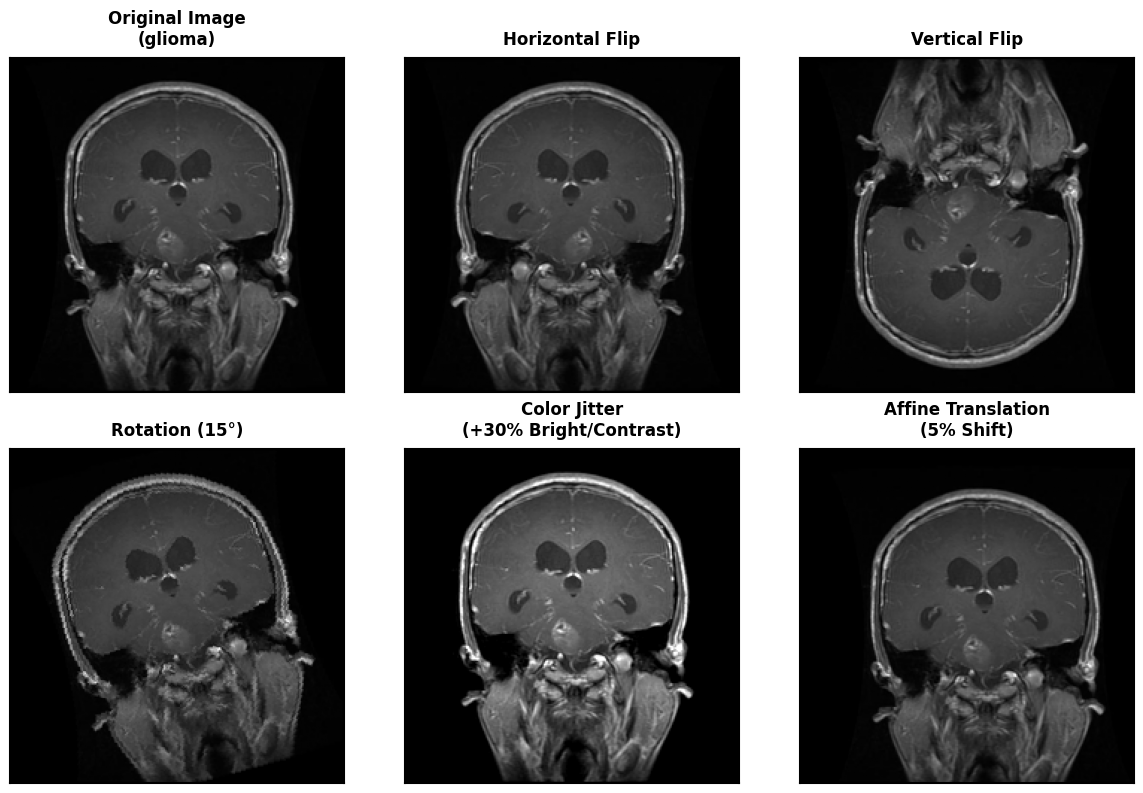

✅ Augmentation grid saved as all_augmentations_grid.png


In [31]:
import os
import random
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F
from PIL import Image

# 1. Grab a random image from the test set
classes = ['glioma', 'meningioma', 'notumor', 'pituitary']
random_class = random.choice(classes)
class_dir = os.path.join(TEST_DIR, random_class)

all_images = [f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
sample_image_path = os.path.join(class_dir, random.choice(all_images))

print(f"🎯 Selected Random Image for Grid: {os.path.basename(sample_image_path)}")

original_img = Image.open(sample_image_path).convert('L')
img_resized = original_img.resize((224, 224))

# 2. Apply explicit, individual transformations for the paper
img_hflip = F.hflip(img_resized)
img_vflip = F.vflip(img_resized)
img_rotate = F.rotate(img_resized, angle=15)

# Combine brightness and contrast for the "Color Jitter" effect
img_jitter = F.adjust_brightness(img_resized, brightness_factor=1.3)
img_jitter = F.adjust_contrast(img_jitter, contrast_factor=1.3)

# 5% translation on a 224x224 image is roughly 11 pixels
img_translate = F.affine(img_resized, angle=0, translate=[11, 11], scale=1.0, shear=0)

# 3. Create a professional 2x3 grid plot
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

# List of images and their exact titles
images = [img_resized, img_hflip, img_vflip, img_rotate, img_jitter, img_translate]
titles = [
    f"Original Image\n({random_class})",
    "Horizontal Flip",
    "Vertical Flip",
    "Rotation (15°)",
    "Color Jitter\n(+30% Bright/Contrast)",
    "Affine Translation\n(5% Shift)"
]

# Plot each one
for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    
    # Add a clean black border around each image (looks great in papers)
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.5)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.savefig('all_augmentations_grid.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Augmentation grid saved as all_augmentations_grid.png")

In [13]:
# import torch
# import matplotlib.pyplot as plt
# import os

# ckpt = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)

# train_losses = ckpt['train_losses']
# test_losses = ckpt['test_losses']
# train_accs = ckpt['train_accs']
# test_accs = ckpt['test_accs']
# test_glioma_recalls = ckpt.get('test_glioma_recalls', [])

# print(f"Epochs trained: {len(test_accs)}")
# print(f"Best test loss: {ckpt['best_test_loss']:.4f}")
# if test_accs:
#     print(f"Best test acc: {max(test_accs):.2f}% (epoch {test_accs.index(max(test_accs))+1})")
# if test_glioma_recalls:
#     print(f"Best glioma recall: {max(test_glioma_recalls):.2f}% (epoch {test_glioma_recalls.index(max(test_glioma_recalls))+1})")

# def ema_smooth(values, alpha=0.15):
#     smoothed, s = [], None
#     for v in values:
#         s = v if s is None else alpha * v + (1 - alpha) * s
#         smoothed.append(s)
#     return smoothed

# ep = range(1, len(test_accs) + 1)
# ncols = 3 if test_glioma_recalls else 2
# fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 5))

# axes[0].plot(ep, ema_smooth(train_losses), color='blue', lw=2, label='Train Loss')
# axes[0].plot(ep, ema_smooth(test_losses), color='orange', lw=2, label='Test Loss')
# axes[0].set(title='Loss per Epoch', xlabel='Epoch', ylabel='Loss')
# axes[0].legend(); axes[0].grid(alpha=0.3)

# axes[1].plot(ep, ema_smooth(train_accs), color='green', lw=2, label='Train Acc')
# axes[1].plot(ep, ema_smooth(test_accs), color='red', lw=2, label='Test Acc')
# axes[1].set(title='Accuracy per Epoch', xlabel='Epoch', ylabel='Accuracy (%)')
# axes[1].legend(); axes[1].grid(alpha=0.3)

# if test_glioma_recalls:
#     axes[2].plot(ep, ema_smooth(test_glioma_recalls), color='purple', lw=2, label='Test Glioma Recall')
#     axes[2].axhline(y=max(test_glioma_recalls), color='purple', linestyle='--', alpha=0.5,
#                     label=f'Peak {max(test_glioma_recalls):.1f}%')
#     axes[2].set(title='Glioma Recall per Epoch', xlabel='Epoch', ylabel='Recall (%)')
#     axes[2].legend(); axes[2].grid(alpha=0.3)

# plt.tight_layout()
# plt.savefig(os.path.join(save_dir, 'training_curves.png'), dpi=150)
# plt.show()
# print("✅ Training curves saved")


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/model_checkpoints/improved_model_checkpoint.pth'

✅ Best model loaded


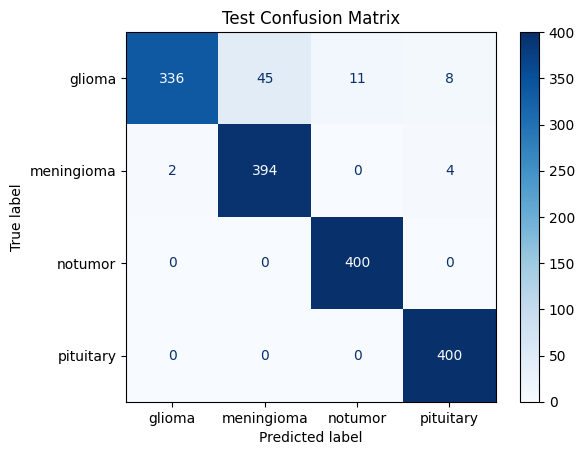

✅ Confusion matrix saved


In [14]:
# Load best model
best_path = BEST_MODEL_PATH if os.path.exists(BEST_MODEL_PATH) else CHECKPOINT_PATH
model.load_state_dict(torch.load(best_path, map_location=device))
model.eval()
print("✅ Best model loaded")

def plot_confusion_matrix(model, loader, device, classes, title, save_path=None):
    model.eval()
    all_labels, all_preds = [], []
    with torch.no_grad():
        for gray, labels in tqdm(loader, desc=title, leave=False):
            gray, labels = gray.to(device), labels.to(device)
            outputs = model(gray, return_aux=False, return_boundary=False)
            _, preds = torch.max(outputs, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=classes)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

plot_confusion_matrix(model, test_loader, device, test_ds.classes,
                      "Test Confusion Matrix",
                      save_path=os.path.join(save_dir, 'cm_test.png'))

print("✅ Confusion matrix saved")

🎯 Selected Random Image: masoud_test_Te-me_180.jpg
🧠 True Class: MENINGIOMA


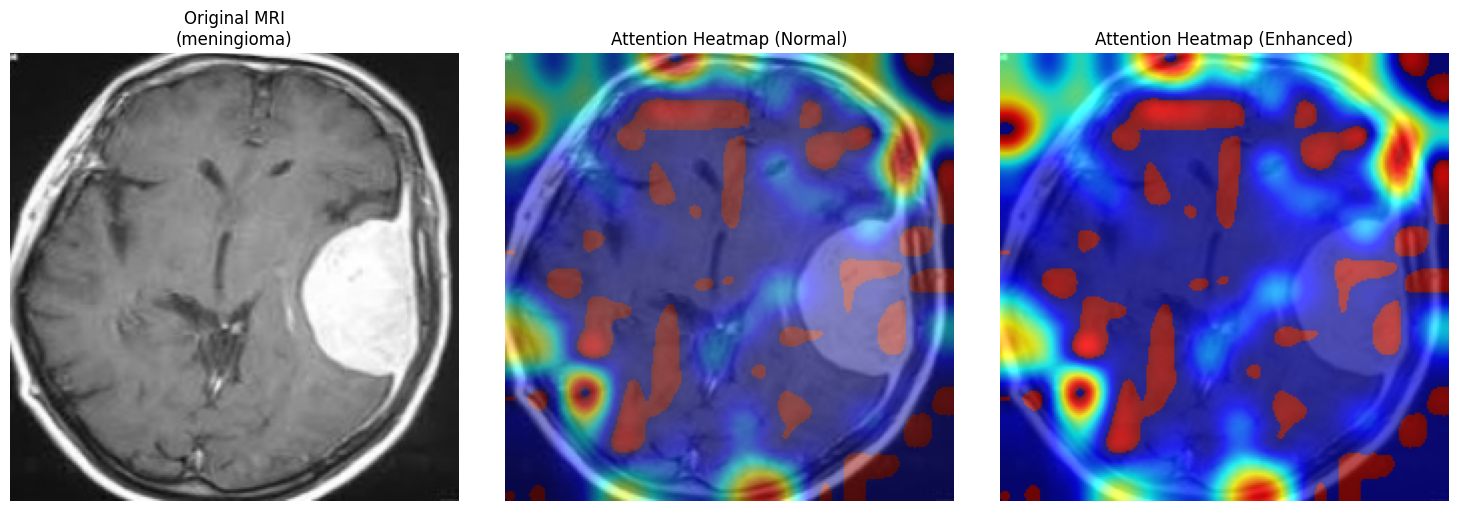

In [30]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image

# 1. Pick a truly random image from the test set
classes = ['glioma', 'meningioma', 'notumor', 'pituitary']
random_class = random.choice(classes)
class_dir = os.path.join(TEST_DIR, random_class)

# Get all valid images in that class folder
all_images = [f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
random_image_name = random.choice(all_images)
sample_image_path = os.path.join(class_dir, random_image_name)

print(f"🎯 Selected Random Image: {random_image_name}")
print(f"🧠 True Class: {random_class.upper()}")

# 2. Function to generate heatmaps
def generate_attention_maps(model, image_path, device):
    model.eval()
    
    # Load and prep the image exactly like the dataset does
    img = Image.open(image_path).convert('L')
    img_tensor = test_transform_gray(img)
    
    # Add coordinate channels (X, Y)
    enhanced_tensor = ImprovedBrainTumorDataset.add_coordinate_channels(img_tensor).unsqueeze(0).to(device)
    
    # Forward pass to grab the attention weights
    with torch.no_grad():
        x_cnn = model.cnn(enhanced_tensor)
        x_aspp = model.apply_aspp(x_cnn)
        x_seq = x_aspp.permute(0, 2, 3, 1).reshape(1, -1, 512)
        
        x = x_seq + model.pos_enc_initial
        attn_out, _ = model.self_attn_1(x, x, x)
        x = model.norm_attn_1(x + attn_out) + model.pos_enc_attn1
        lstm_out, _ = model.bilstm_1(x)
        x = model.norm_lstm_1(x + lstm_out) + model.pos_enc_lstm1
        
        attn_out2, _ = model.self_attn_2(x, x, x)
        x = model.norm_attn_2(x + attn_out2) + model.pos_enc_attn2
        lstm_out2, _ = model.bilstm_2(x)
        x = model.norm_lstm_2(x + lstm_out2) + model.pos_enc_lstm2
        
        # Grab the raw attention weights from your pool_attention layer
        _, attn_weights = model.attention_pool(x) # Shape: (1, 196, 1)

    # Reshape 196 back to 14x14 grid
    attn_map = attn_weights.view(14, 14).cpu().numpy()
    
    # Normalize between 0 and 1
    attn_map = (attn_map - np.min(attn_map)) / (np.max(attn_map) - np.min(attn_map) + 1e-8)
    
    # Resize to 224x224
    attn_map_resized = cv2.resize(attn_map, (224, 224), interpolation=cv2.INTER_CUBIC)
    
    # Create colormap (JET)
    heatmap = cv2.applyColorMap(np.uint8(255 * attn_map_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    
    # Original image in RGB
    orig_np = cv2.resize(np.array(img), (224, 224))
    orig_rgb = cv2.cvtColor(orig_np, cv2.COLOR_GRAY2RGB)
    
    # Superimpose (Normal overlay)
    overlay = cv2.addWeighted(orig_rgb, 0.5, heatmap, 0.5, 0)
    
    # Enhanced Contrast overlay (pushing the alpha higher on the heatmap)
    overlay_enhanced = cv2.addWeighted(orig_rgb, 0.3, heatmap, 0.8, 0)
    
    # Plotting
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(orig_rgb)
    axes[0].set_title(f"Original MRI\n({random_class})")
    axes[0].axis('off')
    
    axes[1].imshow(overlay)
    axes[1].set_title("Attention Heatmap (Normal)")
    axes[1].axis('off')
    
    axes[2].imshow(overlay_enhanced)
    axes[2].set_title("Attention Heatmap (Enhanced)")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.savefig('attention_heatmaps.png', dpi=300, bbox_inches='tight')
    plt.show()

# Run it! 
generate_attention_maps(model, sample_image_path, device)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

def get_all_metrics(model, loader, device, classes):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    with torch.no_grad():
        for gray, labels in tqdm(loader, desc="Evaluating", leave=False):
            gray, labels = gray.to(device), labels.to(device)
            outputs = model(gray, return_aux=False, return_boundary=False)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    print("\n📊 Classification Report:")
    print(classification_report(all_labels, all_preds,
                                target_names=classes, digits=4))
    return all_labels, all_preds, all_probs

all_labels, all_preds, all_probs = get_all_metrics(
    model, test_loader, device, test_ds.classes)


In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

def plot_roc_curve(all_labels, all_probs, classes, title, save_path=None):
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    all_labels_bin = label_binarize(all_labels, classes=range(len(classes)))

    plt.figure(figsize=(10, 7))
    colors = ['blue', 'red', 'green', 'orange']

    for i, (cls, color) in enumerate(zip(classes, colors)):
        fpr, tpr, _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=2,
                 label=f'{cls} (AUC = {roc_auc:.4f})')

    fpr_grid = np.linspace(0, 1, 200)
    mean_tpr = np.zeros_like(fpr_grid)
    for i in range(len(classes)):
        fpr_i, tpr_i, _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
        mean_tpr += np.interp(fpr_grid, fpr_i, tpr_i)
    mean_tpr /= len(classes)
    macro_auc = auc(fpr_grid, mean_tpr)

    plt.plot(fpr_grid, mean_tpr, color='black', lw=2, linestyle='--',
             label=f'Macro Average (AUC = {macro_auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random Classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Macro AUC: {macro_auc:.4f}")

plot_roc_curve(all_labels, all_probs, test_ds.classes,
               "ROC Curve — Test Set",
               save_path=os.path.join(save_dir, 'roc_curve_test.png'))
print("✅ ROC curve saved")


In [ ]:
from sklearn.metrics import precision_recall_fscore_support, matthews_corrcoef, roc_auc_score, accuracy_score, f1_score

def print_summary_table(all_labels, all_preds, all_probs, classes):
    all_labels_bin = label_binarize(all_labels, classes=range(len(classes)))

    acc = accuracy_score(all_labels, all_preds) * 100
    f1_macro = f1_score(all_labels, all_preds, average='macro') * 100
    f1_weighted = f1_score(all_labels, all_preds, average='weighted') * 100
    mcc = matthews_corrcoef(all_labels, all_preds)
    auc_macro = roc_auc_score(all_labels_bin, all_probs,
                              average='macro', multi_class='ovr')

    print("\n" + "="*50)
    print("         FINAL RESULTS SUMMARY")
    print("="*50)
    print(f"  Accuracy          : {acc:.2f}%")
    print(f"  F1 Macro          : {f1_macro:.2f}%")
    print(f"  F1 Weighted       : {f1_weighted:.2f}%")
    print(f"  MCC               : {mcc:.4f}")
    print(f"  AUC-ROC (macro)   : {auc_macro:.4f}")
    print("="*50)

    print("\nPer-Class Results:")
    print(f"{'Class':<15} {'Precision':>10} {'Recall':>10} {'F1':>10} {'AUC':>10}")
    print("-"*55)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average=None)
    for i, cls in enumerate(classes):
        cls_auc = roc_auc_score(all_labels_bin[:, i], all_probs[:, i])
        print(f"{cls:<15} {precision[i]:>10.4f} {recall[i]:>10.4f} "
              f"{f1[i]:>10.4f} {cls_auc:>10.4f}")

print_summary_table(all_labels, all_preds, all_probs, test_ds.classes)


✅ Compact image saved as Compact_Architecture_Graph.png in your working directory!


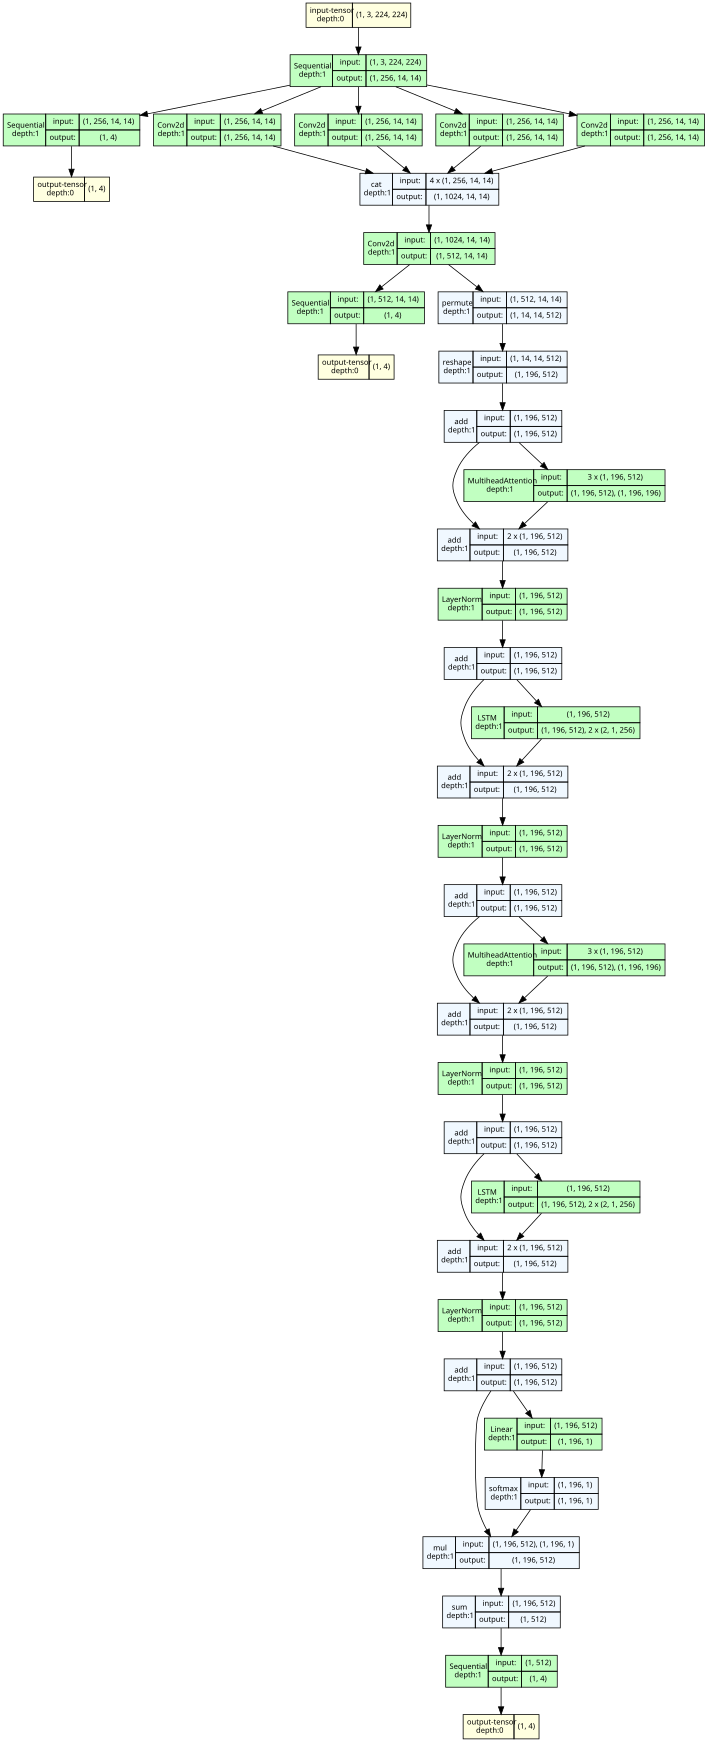

In [36]:
!pip install torchview

import torch
from torchview import draw_graph
import os

# Make sure model is in eval mode
model.eval()

# Create dummy input matching your new architecture (3 channels, 224x224)
dummy_input = torch.randn(1, 3, 224, 224).to(device)

# Generate the graph using Torchview
model_graph = draw_graph(
    model, 
    input_data=dummy_input, 
    device=device,
    expand_nested=True,  
    depth=1,             # ⬅️ CHANGED TO 1: Keeps CNN and Classifier as single, compact boxes!
    save_graph=True,     
    filename="Compact_Architecture_Graph", 
    directory="/kaggle/working/"
)

print("✅ Compact image saved as Compact_Architecture_Graph.png in your working directory!")

# This will display the image right in your Kaggle notebook so you can check it
model_graph.visual_graph